# 💳 PaySim Fraud Detection — Training Notebook

**Dataset:** [PaySim1 on Kaggle](https://www.kaggle.com/datasets/ealaxi/paysim)  
**Goal:** Train a machine learning model to detect fraudulent financial transactions.  

---
## 📌 Dataset Overview
PaySim simulates mobile money transactions based on a sample of real transactions.  
It contains ~6.3 million rows with features like:
- `step` – time step (1 hour)
- `type` – transaction type (CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER)
- `amount` – transaction amount
- `nameOrig` / `nameDest` – sender / receiver IDs
- `oldbalanceOrg` / `newbalanceOrig` – sender balance before/after
- `oldbalanceDest` / `newbalanceDest` – receiver balance before/after
- `isFraud` – target label (1 = fraud, 0 = not fraud)
- `isFlaggedFraud` – system flag for large transfers

## 1. 📦 Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import joblib
import os

# Optional: XGBoost / LightGBM
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed. Skipping.')

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not installed. Skipping.')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 2. 📂 Load Dataset

> **Download instructions:**
> 1. Visit: https://www.kaggle.com/datasets/ealaxi/paysim
> 2. Download `PS_20174392719_1491204439457_log.csv`
> 3. Place it in the same directory as this notebook (or update `DATA_PATH` below).

In [7]:
# ── Configuration ──────────────────────────────────────────
DATA_PATH = '/Users/kaustavmanideka/Documents/projects/ML/files/data/PS_20174392719_1491204439457_log.csv'  # Update path if needed
RANDOM_STATE = 42
TEST_SIZE = 0.2
MODEL_SAVE_PATH = 'fraud_model.pkl'
SCALER_SAVE_PATH = 'scaler.pkl'
TRAIN_DATA_SAVE = 'train_data.csv'
TEST_DATA_SAVE  = 'test_data.csv'
# ───────────────────────────────────────────────────────────

print(f'Loading dataset from: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)
print(f'✅ Dataset loaded! Shape: {df.shape}')
df.head()

Loading dataset from: /Users/kaustavmanideka/Documents/projects/ML/files/data/PS_20174392719_1491204439457_log.csv
✅ Dataset loaded! Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3. 🔍 Exploratory Data Analysis (EDA)

In [8]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB

=== Missing Values ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== Basic Statistics ===


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


=== Class Distribution ===
Not Fraud (0): 6,354,407 (99.8709%)
Fraud     (1): 8,213 (0.1291%)


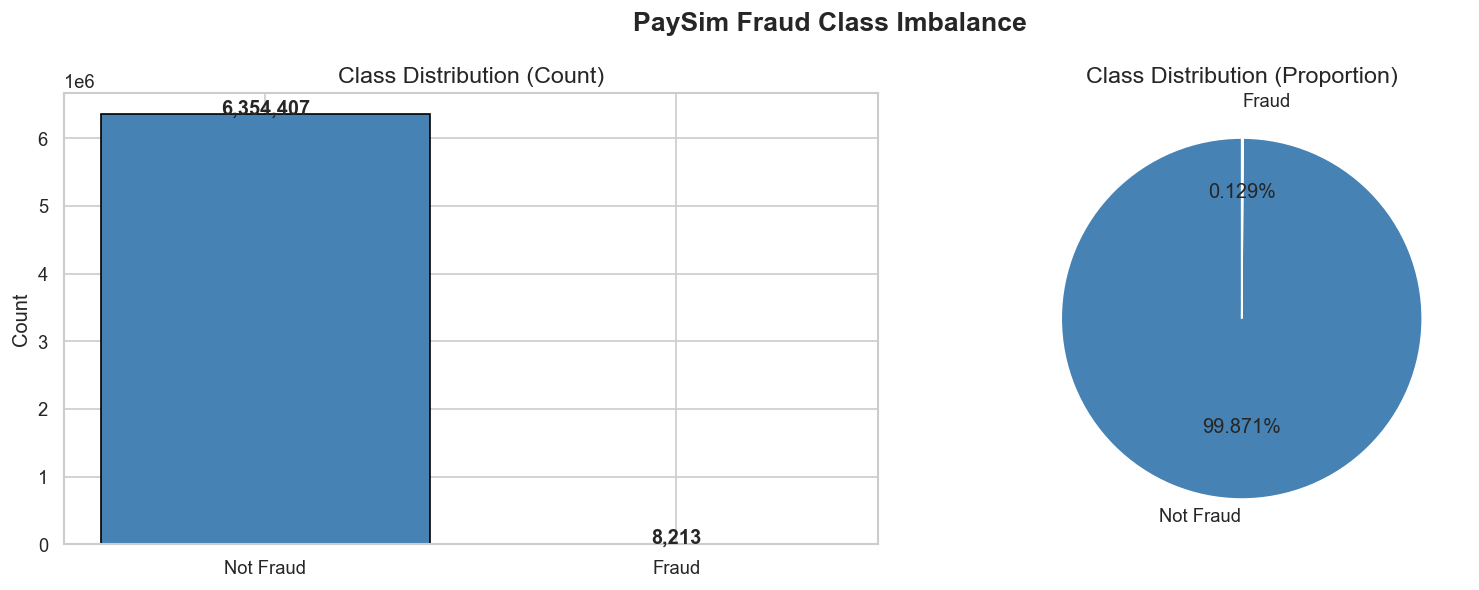

In [9]:
# Class distribution
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print('=== Class Distribution ===')
print(f"Not Fraud (0): {fraud_counts[0]:,} ({fraud_pct[0]:.4f}%)")
print(f"Fraud     (1): {fraud_counts[1]:,} ({fraud_pct[1]:.4f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(['Not Fraud', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Not Fraud', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'crimson'],
            startangle=90, explode=[0, 0.1])
axes[1].set_title('Class Distribution (Proportion)', fontsize=14)

plt.suptitle('PaySim Fraud Class Imbalance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
# Transaction type analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Transactions by Type', fontsize=14)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Fraud by transaction type
fraud_by_type = df[df['isFraud'] == 1]['type'].value_counts()
axes[1].bar(fraud_by_type.index, fraud_by_type.values, color='crimson', edgecolor='black')
axes[1].set_title('Fraudulent Transactions by Type', fontsize=14)
axes[1].set_ylabel('Fraud Count')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Transaction Type Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('transaction_types.png', bbox_inches='tight')
plt.show()

print('\n⚠️  Key Insight: Fraud only occurs in TRANSFER and CASH_OUT transactions!')

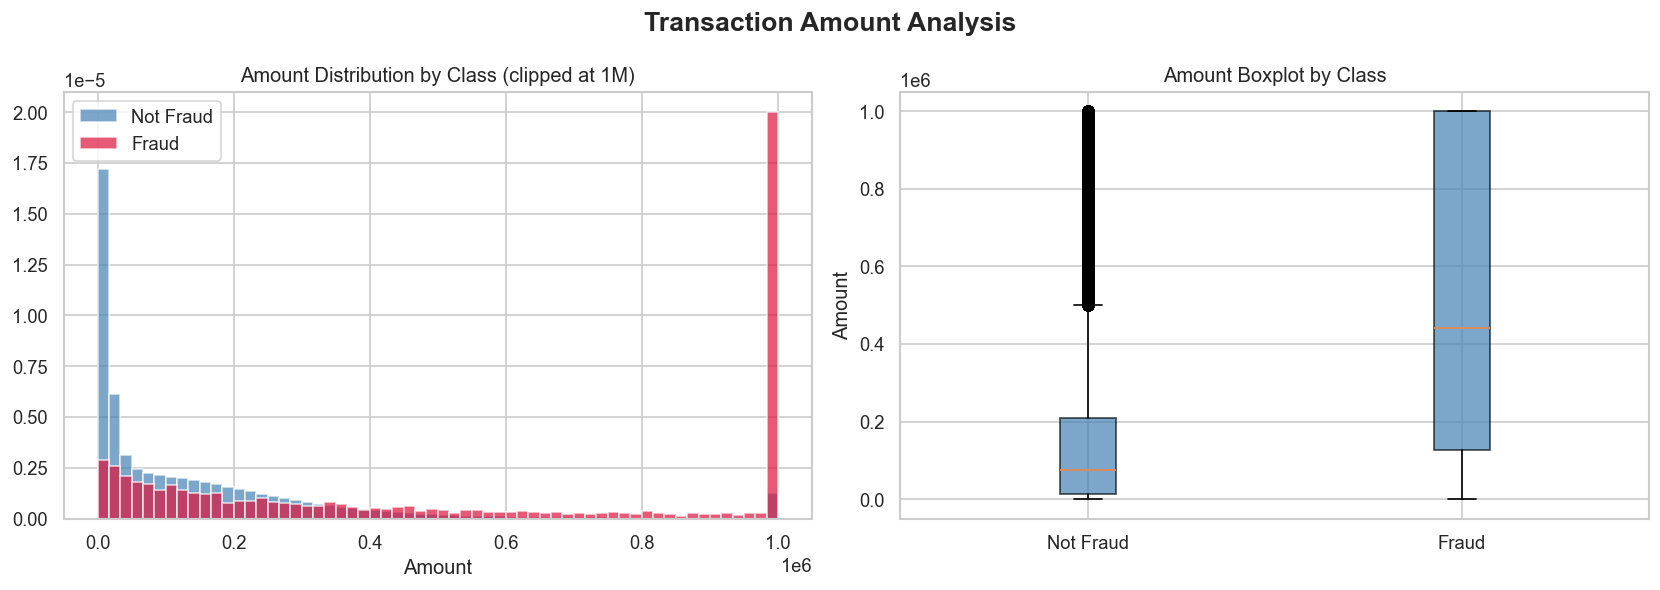

In [10]:
# Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['isFraud'] == 0]['amount'].clip(upper=1e6),
             bins=60, color='steelblue', alpha=0.7, label='Not Fraud', density=True)
axes[0].hist(df[df['isFraud'] == 1]['amount'].clip(upper=1e6),
             bins=60, color='crimson', alpha=0.7, label='Fraud', density=True)
axes[0].set_title('Amount Distribution by Class (clipped at 1M)', fontsize=12)
axes[0].set_xlabel('Amount')
axes[0].legend()

# Box plot
df_box = df[['amount', 'isFraud']].copy()
df_box['Class'] = df_box['isFraud'].map({0: 'Not Fraud', 1: 'Fraud'})
axes[1].boxplot(
    [df[df['isFraud']==0]['amount'].clip(upper=1e6),
     df[df['isFraud']==1]['amount'].clip(upper=1e6)],
    labels=['Not Fraud', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7)
)
axes[1].set_title('Amount Boxplot by Class', fontsize=12)
axes[1].set_ylabel('Amount')

plt.suptitle('Transaction Amount Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('amount_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
## 4. 🛠️ Feature Engineering

In [11]:
def engineer_features(data):
    df_fe = data.copy()
    
    # Balance error features (common fraud indicator)
    df_fe['errorBalanceOrig'] = (df_fe['newbalanceOrig']
                                 + df_fe['amount']
                                 - df_fe['oldbalanceOrg'])
    df_fe['errorBalanceDest'] = (df_fe['oldbalanceDest']
                                 + df_fe['amount']
                                 - df_fe['newbalanceDest'])
    
    # Ratio features
    df_fe['amountRatioOrig'] = df_fe['amount'] / (df_fe['oldbalanceOrg'] + 1)
    df_fe['amountRatioDest'] = df_fe['amount'] / (df_fe['oldbalanceDest'] + 1)
    
    # Balance changed to zero flag (common in fraud)
    df_fe['origBalanceZero'] = ((df_fe['newbalanceOrig'] == 0) &
                                (df_fe['oldbalanceOrg'] != 0)).astype(int)
    df_fe['destBalanceUnchanged'] = (df_fe['oldbalanceDest'] == df_fe['newbalanceDest']).astype(int)

    # Time features
    df_fe['hour'] = df_fe['step'] % 24
    df_fe['day']  = df_fe['step'] // 24
    
    # Encode transaction type
    le = LabelEncoder()
    df_fe['type_encoded'] = le.fit_transform(df_fe['type'])
    
    return df_fe, le

df_fe, label_encoder = engineer_features(df)
print('✅ Feature engineering complete!')
print(f'New features added: errorBalanceOrig, errorBalanceDest, amountRatioOrig, amountRatioDest,')
print(f'                    origBalanceZero, destBalanceUnchanged, hour, day, type_encoded')
df_fe.head(3)

✅ Feature engineering complete!
New features added: errorBalanceOrig, errorBalanceDest, amountRatioOrig, amountRatioDest,
                    origBalanceZero, destBalanceUnchanged, hour, day, type_encoded


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,amountRatioOrig,amountRatioDest,origBalanceZero,destBalanceUnchanged,hour,day,type_encoded
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64,0.057834,9839.64,0,1,1,0,3
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28,0.087731,1864.28,0,1,1,0,3
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,181.00,0.994505,181.00,1,1,1,0,4


## 5. 🧩 Prepare Features & Split Data

In [12]:
FEATURE_COLS = [
    'step', 'type_encoded', 'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'amountRatioOrig', 'amountRatioDest',
    'origBalanceZero', 'destBalanceUnchanged',
    'hour', 'day'
]

TARGET_COL = 'isFraud'

X = df_fe[FEATURE_COLS]
y = df_fe[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set   : {X_train.shape[0]:,} rows')
print(f'Test set       : {X_test.shape[0]:,} rows')
print(f'\nFraud rate - Train: {y_train.mean()*100:.4f}%')
print(f'Fraud rate - Test : {y_test.mean()*100:.4f}%')

Training set   : 5,090,096 rows
Test set       : 1,272,524 rows

Fraud rate - Train: 0.1291%
Fraud rate - Test : 0.1291%


In [13]:
# Save train/test splits for test notebook
train_df = X_train.copy()
train_df[TARGET_COL] = y_train.values
train_df.to_csv(TRAIN_DATA_SAVE, index=False)

test_df = X_test.copy()
test_df[TARGET_COL] = y_test.values
test_df.to_csv(TEST_DATA_SAVE, index=False)

print(f'✅ Saved train data → {TRAIN_DATA_SAVE}')
print(f'✅ Saved test data  → {TEST_DATA_SAVE}')

✅ Saved train data → train_data.csv
✅ Saved test data  → test_data.csv


In [36]:
# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

joblib.dump(scaler, SCALER_SAVE_PATH)
print(f'✅ Scaler saved → {SCALER_SAVE_PATH}')

✅ Scaler saved → scaler.pkl


## 6. 🤖 Model Training

We handle class imbalance using **class_weight='balanced'** (or `scale_pos_weight` for XGBoost).

In [35]:
# Compute class weights
classes = np.array([0, 1])
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))
scale_pos = cw[1] / cw[0]  # for XGBoost

print(f'Class weights: {class_weight_dict}')
print(f'scale_pos_weight for XGBoost: {scale_pos:.2f}')

Class weights: {np.int64(0): np.float64(0.5006462050159672), np.int64(1): np.float64(387.37412480974126)}
scale_pos_weight for XGBoost: 773.75


In [32]:
# ── Random Forest ──────────────────────────────────────────
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print('\n📊 Random Forest Results:')
print(classification_report(y_test, rf_pred, target_names=['Not Fraud', 'Fraud']))
print(f'ROC-AUC : {roc_auc_score(y_test, rf_proba):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, rf_proba):.4f}')

Training Random Forest...

📊 Random Forest Results:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1270881
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC : 0.9994
PR-AUC  : 0.9987


In [33]:
# ── XGBoost (if available) ─────────────────────────────────
if XGBOOST_AVAILABLE:
    print('Training XGBoost...')
    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        eval_metric='aucpr',
        use_label_encoder=False,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)
    xgb_pred  = xgb_model.predict(X_test)
    xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

    print('\n📊 XGBoost Results:')
    print(classification_report(y_test, xgb_pred, target_names=['Not Fraud', 'Fraud']))
    print(f'ROC-AUC : {roc_auc_score(y_test, xgb_proba):.4f}')
    print(f'PR-AUC  : {average_precision_score(y_test, xgb_proba):.4f}')
else:
    print('XGBoost not available. Install with: pip install xgboost')

Training XGBoost...

📊 XGBoost Results:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1270881
       Fraud       0.99      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC : 0.9996
PR-AUC  : 0.9981


In [34]:
# ── LightGBM (if available) ────────────────────────────────
if LGBM_AVAILABLE:
    print('Training LightGBM...')
    lgbm_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    lgbm_model.fit(X_train, y_train)
    lgbm_pred  = lgbm_model.predict(X_test)
    lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]

    print('\n📊 LightGBM Results:')
    print(classification_report(y_test, lgbm_pred, target_names=['Not Fraud', 'Fraud']))
    print(f'ROC-AUC : {roc_auc_score(y_test, lgbm_proba):.4f}')
    print(f'PR-AUC  : {average_precision_score(y_test, lgbm_proba):.4f}')
else:
    print('LightGBM not available. Install with: pip install lightgbm')

Training LightGBM...
[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2614
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

📊 LightGBM Results:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1270881
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC : 0.9999
PR-AUC  : 0.9984


## 7. 📊 Model Comparison & Selection

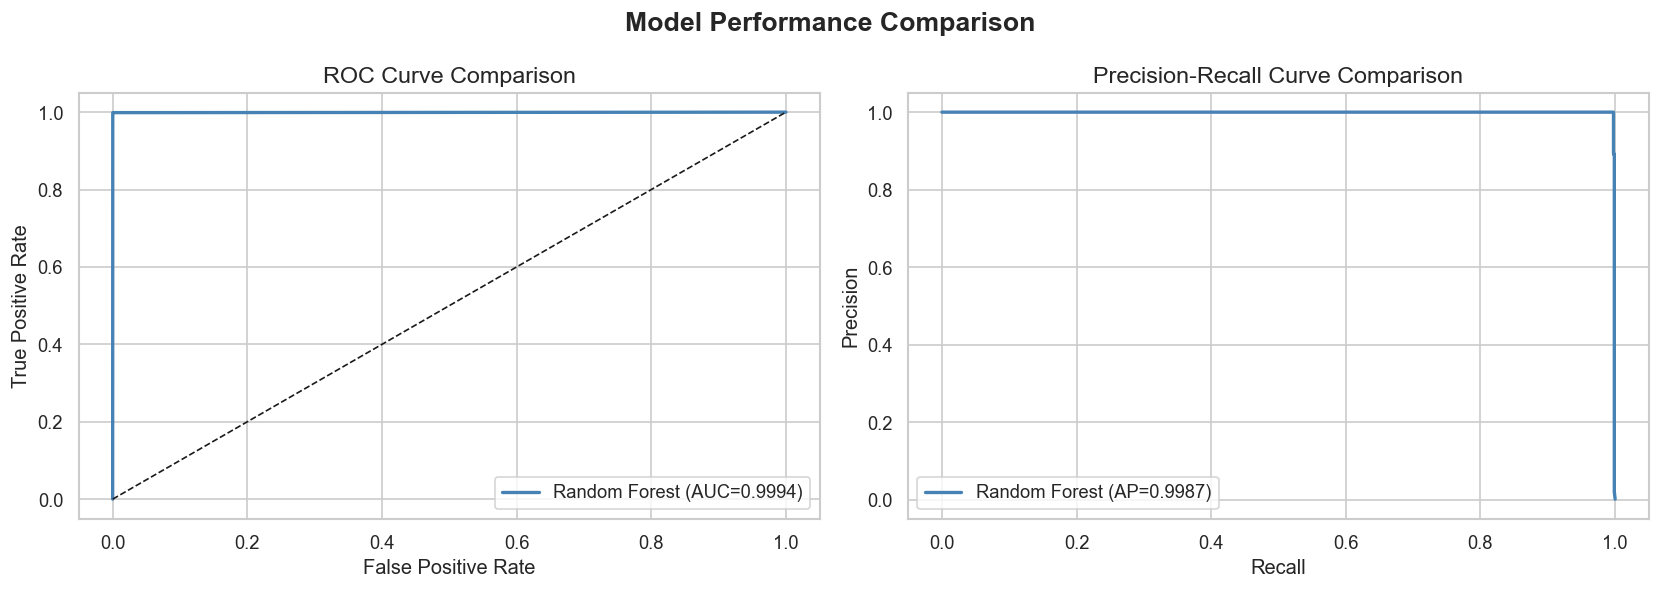

In [24]:
# Compare ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_results = {'Random Forest': (rf_pred, rf_proba)}
if XGBOOST_AVAILABLE: models_results['XGBoost'] = (xgb_pred, xgb_proba)
if LGBM_AVAILABLE:    models_results['LightGBM'] = (lgbm_pred, lgbm_proba)

colors = ['steelblue', 'crimson', 'forestgreen', 'orange']

# ROC Curve
for (name, (pred, proba)), color in zip(models_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontsize=14)
axes[0].legend()

# Precision-Recall Curve
for (name, (pred, proba)), color in zip(models_results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, label=f'{name} (AP={ap:.4f})', color=color, lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison', fontsize=14)
axes[1].legend()

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

In [25]:
# Select best model (by ROC-AUC)
model_aucs = {name: roc_auc_score(y_test, proba)
              for name, (pred, proba) in models_results.items()}

best_model_name = max(model_aucs, key=model_aucs.get)
print(f'\n🏆 Best Model: {best_model_name} (ROC-AUC = {model_aucs[best_model_name]:.4f})')

# Map to actual model object
model_map = {'Random Forest': rf_model}
if XGBOOST_AVAILABLE: model_map['XGBoost'] = xgb_model
if LGBM_AVAILABLE:    model_map['LightGBM'] = lgbm_model

best_model = model_map[best_model_name]
joblib.dump(best_model, MODEL_SAVE_PATH)
print(f'✅ Best model saved → {MODEL_SAVE_PATH}')


🏆 Best Model: Random Forest (ROC-AUC = 0.9994)
✅ Best model saved → fraud_model.pkl


## 8. 🔥 Feature Importance

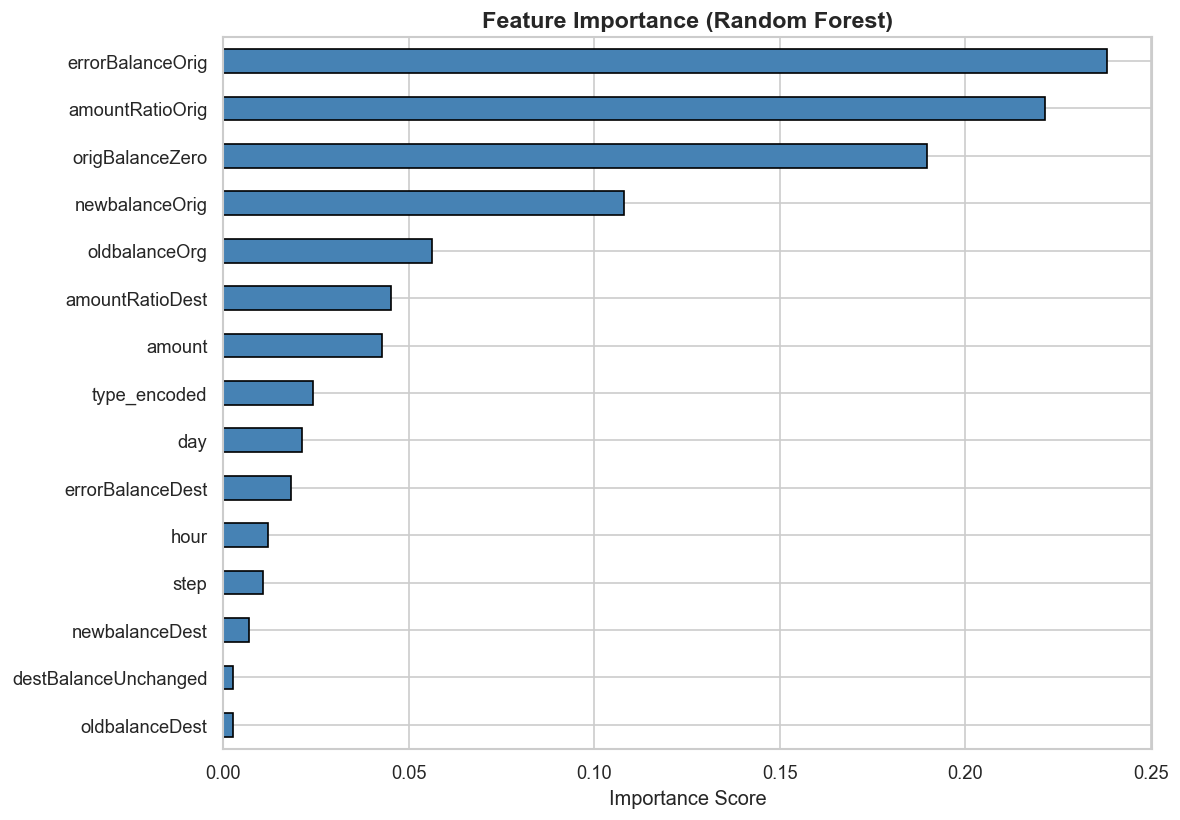

In [26]:
# Feature importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## 9. 🎯 Confusion Matrix (Best Model)

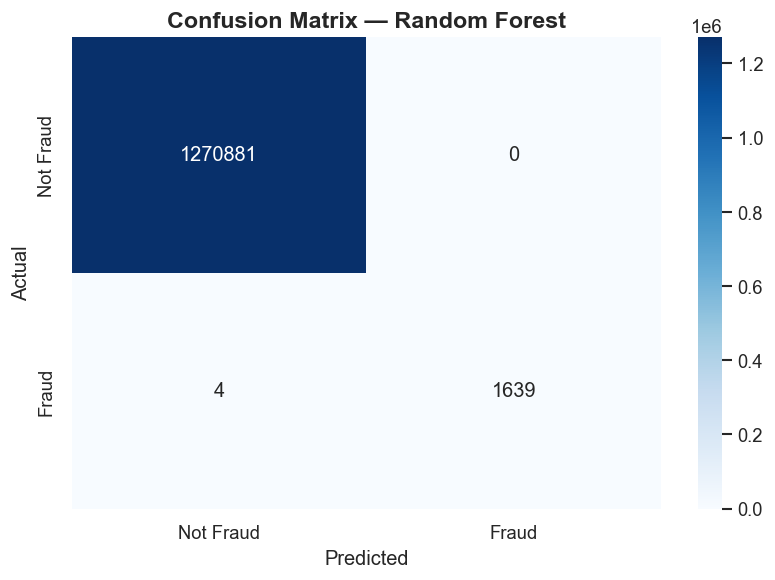

True Negatives  (TN): 1,270,881
False Positives (FP): 0  ← legitimate flagged as fraud
False Negatives (FN): 4  ← fraud missed!
True Positives  (TP): 1,639


In [27]:
best_pred = model_map[best_model_name].predict(X_test)
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'], ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_train.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn:,}')
print(f'False Positives (FP): {fp:,}  ← legitimate flagged as fraud')
print(f'False Negatives (FN): {fn:,}  ← fraud missed!')
print(f'True Positives  (TP): {tp:,}')

## 10. 💾 Save Artifacts Summary

In [28]:
print('='*50)
print('   TRAINING COMPLETE — Saved Artifacts')
print('='*50)

artifacts = [
    (MODEL_SAVE_PATH,      'Trained best model'),
    (SCALER_SAVE_PATH,     'Feature scaler (StandardScaler)'),
    (TRAIN_DATA_SAVE,      'Training split (for reference)'),
    (TEST_DATA_SAVE,       '⭐ Test split → used in test_notebook.ipynb'),
]

for path, desc in artifacts:
    size = os.path.getsize(path) / 1024
    print(f'  📁 {path:<30} {size:>8.1f} KB   — {desc}')

print('\n➡️  Open test_fraud_detection.ipynb to evaluate on the test set!')

   TRAINING COMPLETE — Saved Artifacts
  📁 fraud_model.pkl                  1899.1 KB   — Trained best model
  📁 scaler.pkl                          1.4 KB   — Feature scaler (StandardScaler)
  📁 train_data.csv                 535896.1 KB   — Training split (for reference)
  📁 test_data.csv                  133966.3 KB   — ⭐ Test split → used in test_notebook.ipynb

➡️  Open test_fraud_detection.ipynb to evaluate on the test set!
